# Fraud Detection Data Analysis

**Members:**
##Awais iftikhar FA24-BBD-034
##Muhammad Umar FA24-BBD-150
##Mehr Mohyuddin FA24-BBD-094

## Step 1: Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/Fraud Detection Dataset.csv")

print(df.shape)
print(df.dtypes)
print(df.head())

(51000, 12)
Transaction_ID                       object
User_ID                               int64
Transaction_Amount                  float64
Transaction_Type                     object
Time_of_Transaction                 float64
Device_Used                          object
Location                             object
Previous_Fraudulent_Transactions      int64
Account_Age                           int64
Number_of_Transactions_Last_24H       int64
Payment_Method                       object
Fraudulent                            int64
dtype: object
  Transaction_ID  User_ID  Transaction_Amount Transaction_Type  \
0             T1     4174             1292.76   ATM Withdrawal   
1             T2     4507             1554.58   ATM Withdrawal   
2             T3     1860             2395.02   ATM Withdrawal   
3             T4     2294              100.10     Bill Payment   
4             T5     2130             1490.50      POS Payment   

   Time_of_Transaction Device_Used       Location

## Step 2: Data Cleaning

In [10]:
# check missing values
print(df.isnull().sum())

# fill missing values
df['Transaction_Amount'] = df['Transaction_Amount'].fillna(df['Transaction_Amount'].median())
df['Time_of_Transaction'] = df['Time_of_Transaction'].fillna(df['Time_of_Transaction'].median())
df['Location'] = df['Location'].fillna('Unknown')
df['Device_Used'] = df['Device_Used'].fillna('Unknown')
df['Payment_Method'] = df['Payment_Method'].fillna('Unknown')

# confirm
print(df.isnull().sum())

Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
z_score_amount                      0
z_score_transactions                0
is_outlier                          0
fraud_risk_score                    0
dtype: int64
Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0

 ## Step 3: Exploratory Data Analysis

Fraudulent
0    48490
1     2510
Name: count, dtype: int64
Fraudulent
0    2966.923142
1    3088.772263
Name: Transaction_Amount, dtype: float64
Transaction_Type
ATM Withdrawal     473
Bank Transfer      494
Bill Payment       512
Online Purchase    524
POS Payment        507
Name: Fraudulent, dtype: int64
Device_Used
Desktop           748
Mobile            806
Tablet            729
Unknown           152
Unknown Device     75
Name: Fraudulent, dtype: int64
Payment_Method
Credit Card       574
Debit Card        572
Invalid Method     73
Net Banking       574
UPI               612
Unknown           105
Name: Fraudulent, dtype: int64


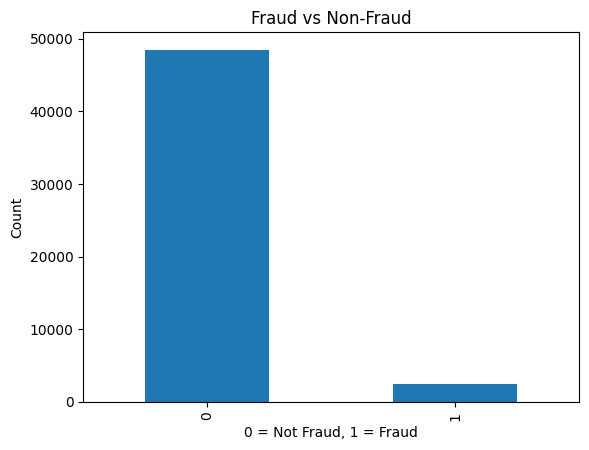

In [4]:
# fraud vs non-fraud count
print(df['Fraudulent'].value_counts())

# transaction amount by fraud status
print(df.groupby('Fraudulent')['Transaction_Amount'].mean())

# fraud by transaction type
print(df.groupby('Transaction_Type')['Fraudulent'].sum())

# fraud by device
print(df.groupby('Device_Used')['Fraudulent'].sum())

# fraud by payment method
print(df.groupby('Payment_Method')['Fraudulent'].sum())

# simple chart
df['Fraudulent'].value_counts().plot(kind='bar', title='Fraud vs Non-Fraud')
plt.xlabel('0 = Not Fraud, 1 = Fraud')
plt.ylabel('Count')
plt.show()

## Step 4: Outlier Detection using Z-Score

In [ ]:
# calculate z-scores
df['z_score_amount'] = (df['Transaction_Amount'] - df['Transaction_Amount'].mean()) / df['Transaction_Amount'].std()
df['z_score_transactions'] = (df['Number_of_Transactions_Last_24H'] - df['Number_of_Transactions_Last_24H'].mean()) / df['Number_of_Transactions_Last_24H'].std()

# identify outliers
df['is_outlier'] = (abs(df['z_score_amount']) > 3) | (abs(df['z_score_transactions']) > 3)

# check how many outliers found
print(df['is_outlier'].value_counts())

# see how many outliers are actually fraudulent
print(df[df['is_outlier'] == True]['Fraudulent'].value_counts())

is_outlier
False    50492
True       508
Name: count, dtype: int64
Fraudulent
0    476
1     32
Name: count, dtype: int64


## Step 5: User Behavior Analysis

In [6]:
# group by user
user_stats = df.groupby('User_ID').agg(
    total_transactions = ('Transaction_ID', 'count'),
    avg_amount = ('Transaction_Amount', 'mean'),
    total_fraud = ('Fraudulent', 'sum'),
    prev_fraud = ('Previous_Fraudulent_Transactions', 'sum')
).reset_index()

print(user_stats.head())

# high risk users
high_risk = user_stats[user_stats['total_fraud'] > 0]
print("\nHigh risk users:", len(high_risk))
print(high_risk.sort_values('total_fraud', ascending=False).head(10))

   User_ID  total_transactions   avg_amount  total_fraud  prev_fraud
0     1000                  11  2232.880000            0          24
1     1001                  11  1997.949091            1          27
2     1002                   8  1969.753750            0           7
3     1003                  11  1770.486364            0          32
4     1004                   8  2926.672500            0          22

High risk users: 1857
      User_ID  total_transactions   avg_amount  total_fraud  prev_fraud
2134     3134                  28  5876.279643            5          57
2738     3738                  18  2592.067222            5          37
3614     4614                  16  2509.985625            5          44
1934     2934                  18  2811.835556            5          38
1785     2785                   8  1425.152500            4          14
1603     2603                  17  2558.800000            4          25
3681     4681                  18  4910.033333            4

## Step 6: Fraud Risk Score

In [11]:
# start with 0
df['fraud_risk_score'] = 0

# add points for each risk factor
df['fraud_risk_score'] += (abs(df['z_score_amount']) > 3) * 30
df['fraud_risk_score'] += (abs(df['z_score_transactions']) > 3) * 20
df['fraud_risk_score'] += (df['Previous_Fraudulent_Transactions'] > 0) * 30
df['fraud_risk_score'] += (df['Number_of_Transactions_Last_24H'] > 10) * 20

print(df[['Transaction_ID', 'Fraudulent', 'fraud_risk_score']].head(10))
print("Average risk score by fraud status:")
print(df.groupby('Fraudulent')['fraud_risk_score'].mean())

  Transaction_ID  Fraudulent  fraud_risk_score
0             T1           0                20
1             T2           0                30
2             T3           0                30
3             T4           0                30
4             T5           0                30
5             T6           0                50
6             T7           1                30
7             T8           0                30
8             T9           0                50
9            T10           0                30
Average risk score by fraud status:
Fraudulent
0    29.937100
1    30.250996
Name: fraud_risk_score, dtype: float64


## Step 7: Summary Statistics & Correlation

In [8]:
# summary stats
print(df.describe())

# correlation
corr = df[['Transaction_Amount', 'Previous_Fraudulent_Transactions',
           'Account_Age', 'Number_of_Transactions_Last_24H', 'fraud_risk_score', 'Fraudulent']].corr()
print(corr)


            User_ID  Transaction_Amount  Time_of_Transaction  \
count  51000.000000        51000.000000          51000.00000   
mean    3005.110176         2972.920030             11.51400   
std     1153.121107         4918.801144              6.74844   
min     1000.000000            5.030000              0.00000   
25%     2007.000000         1333.787500              6.00000   
50%     2996.000000         2524.100000             12.00000   
75%     4006.000000         3724.987500             17.00000   
max     4999.000000        49997.800000             23.00000   

       Previous_Fraudulent_Transactions   Account_Age  \
count                      51000.000000  51000.000000   
mean                           1.995725     60.033902   
std                            1.415150     34.384131   
min                            0.000000      1.000000   
25%                            1.000000     30.000000   
50%                            2.000000     60.000000   
75%                     

## Step 8: Final Output

In [ ]:
# save cleaned dataset with risk score
df.to_csv('fraud_detection_output.csv', index=False)

# top 10 high risk 
top_risk = df[['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Fraudulent', 'fraud_risk_score']]
top_risk = top_risk.sort_values('fraud_risk_score', ascending=False).head(10)
print("Top 10 High Risk Transactions:")
print(top_risk)



Top 10 High Risk Transactions:
      Transaction_ID  User_ID  Transaction_Amount  Fraudulent  \
41022         T41023     1356             49997.8           0   
7751           T7752     3309             49997.8           0   
7539           T7540     2938             49997.8           0   
15534         T15535     3723             49997.8           0   
317             T318     4681             49997.8           0   
29866         T29867     3134             49997.8           0   
8540           T8541     3670             49997.8           1   
6915           T6916     1636             49997.8           0   
1645           T1646     2107             49997.8           0   
12938         T12939     4317             49997.8           0   

       fraud_risk_score  
41022                80  
7751                 80  
7539                 80  
15534                80  
317                  80  
29866                80  
8540                 80  
6915                 80  
1645               